# Crop Pest SVM Classifier
Multi-feature fusion: HSV Histogram + Hu Moments + LBP + HOG + Contour Geometry + GLCM Haralick

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

import os
import pickle
import cv2
import numpy as np
from tqdm import tqdm
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

from shared import (
    resolve_paths, yolo_box_to_xyxy, clamp_xyxy,
    plot_confusion_matrix, save_classification_report,
)
from feature_extraction import extract_features, create_hog_descriptor

PROJECT_ROOT, DATA_ROOT, OUT_ROOT = resolve_paths()

FEATURE_CACHE_DIR = Path(OUT_ROOT) / "svm_cache"
FEATURE_CACHE_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT: f:\github\agro-pest
DATA_ROOT:    f:\github\agro-pest\archive
OUT_ROOT:     f:\github\agro-pest\runs
Data exists:  True


In [2]:
CONFIG = {
    "YOLO_ROOT": DATA_ROOT,
    "OUT_ROOT": OUT_ROOT,

    "CLASS_NAMES": [
        "Ants", "Bees", "Beetles", "Caterpillars", "Earthworms", "Earwigs",
        "Grasshoppers", "Moths", "Slugs", "Snails", "Wasps", "Weevils",
    ],

    "CROP_MARGIN_RATIO": 0.05,
    "MIN_CROP_SIZE": 20,
    "RESIZE_TO": (64, 64),

    "SVM_KERNEL": "rbf",
    "SVM_C": 10,
    "SVM_GAMMA": "scale",
    "SVM_CACHE_SIZE": 2000,
}

cfg = CONFIG

In [3]:
def load_paths(folder):
    images_folder = os.path.join(folder, "images")
    labels_folder = os.path.join(folder, "labels")
    image_paths = sorted(
        [os.path.join(images_folder, f) for f in os.listdir(images_folder)]
    )
    label_paths = sorted(
        [os.path.join(labels_folder, f) for f in os.listdir(labels_folder)]
    )
    return image_paths, label_paths


def extract_dataset_features(image_paths, label_paths, hog_desc, margin_ratio=0.05, min_crop=20, resize_to=(64, 64), desc="Extracting"):
    X = []
    y = []
    for img_path, label_path in tqdm(zip(image_paths, label_paths), total=len(image_paths), desc=desc):
        img = cv2.imread(img_path)
        if img is None:
            continue
        H, W = img.shape[:2]
        with open(label_path, "r") as f:
            lines = [ln for ln in f.read().strip().splitlines() if ln.strip()]
        for line in lines:
            cid, xyxy = yolo_box_to_xyxy(line, W, H)
            if cid is None or xyxy is None:
                continue
            xyxy = clamp_xyxy(xyxy, W, H, margin_ratio=margin_ratio)
            if xyxy is None:
                continue
            x1, y1, x2, y2 = xyxy
            roi = img[y1:y2, x1:x2]
            if roi.size == 0 or roi.shape[0] < min_crop or roi.shape[1] < min_crop:
                continue
            roi = cv2.resize(roi, resize_to)
            feature = extract_features(roi, hog_desc)
            X.append(feature)
            y.append(cid)
        del img
    return np.array(X), np.array(y)


def save_features(cache_path, X, y):
    data = {"X": X, "y": y}
    with open(cache_path, "wb") as f:
        pickle.dump(data, f)
    print(f"Features saved to {cache_path}")


def load_features(cache_path):
    with open(cache_path, "rb") as f:
        data = pickle.load(f)
    print(f"Features loaded from {cache_path}")
    return data.get("X"), data.get("y")

In [4]:
USE_CACHE = True
cache_file = FEATURE_CACHE_DIR / "train_features.pkl"

if USE_CACHE and cache_file.exists():
    X_train, y_train = load_features(cache_file)
    hog_desc = create_hog_descriptor()
else:
    train_folder = os.path.join(cfg["YOLO_ROOT"], "train")
    train_image_paths, train_label_paths = load_paths(train_folder)
    hog_desc = create_hog_descriptor()
    X_train, y_train = extract_dataset_features(
        train_image_paths, train_label_paths, hog_desc,
        margin_ratio=cfg["CROP_MARGIN_RATIO"],
        min_crop=cfg["MIN_CROP_SIZE"],
        resize_to=cfg["RESIZE_TO"],
        desc="Train",
    )
    save_features(cache_file, X_train, y_train)

print(f"Training samples: {len(X_train)}, Feature dim: {X_train.shape[1]}")

unique, counts = np.unique(y_train, return_counts=True)
print("Class distribution:", dict(zip(unique, counts)))

Train: 100%|██████████| 11502/11502 [01:08<00:00, 168.40it/s]


Features saved to f:\github\agro-pest\runs\svm_cache\train_features.pkl
Training samples: 15255, Feature dim: 2356
Class distribution: {0: 2221, 1: 1592, 2: 1058, 3: 1733, 4: 1083, 5: 1182, 6: 1071, 7: 1062, 8: 918, 9: 1196, 10: 1167, 11: 972}


In [5]:
model_cache_file = FEATURE_CACHE_DIR / "svm_model.pkl"

if USE_CACHE and model_cache_file.exists():
    model = joblib.load(model_cache_file)
    print(f"Model loaded from {model_cache_file}")
else:
    model = make_pipeline(
        StandardScaler(),
        SVC(
            kernel=cfg["SVM_KERNEL"],
            C=cfg["SVM_C"],
            gamma=cfg["SVM_GAMMA"],
            cache_size=cfg["SVM_CACHE_SIZE"],
            class_weight="balanced",
            verbose=True,
        ),
    )
    model.fit(X_train, y_train)
    print("SVM training complete")

    joblib.dump(model, model_cache_file)
    print(f"Model saved to {model_cache_file}")

[LibSVM]SVM training complete
Model saved to f:\github\agro-pest\runs\svm_cache\svm_model.pkl


Test: 100%|██████████| 546/546 [00:06<00:00, 85.52it/s] 


Features saved to f:\github\agro-pest\runs\svm_cache\test_features.pkl
Test samples: 689
Test accuracy: 0.5036
              precision    recall  f1-score   support

        Ants     0.5288    0.6322    0.5759        87
        Bees     0.4118    0.6364    0.5000        44
     Beetles     0.2439    0.2273    0.2353        44
Caterpillars     0.4354    0.6882    0.5333        93
  Earthworms     0.4524    0.4750    0.4634        40
     Earwigs     0.4167    0.2055    0.2752        73
Grasshoppers     0.3617    0.3091    0.3333        55
       Moths     0.8205    0.6809    0.7442        47
       Slugs     0.5333    0.3137    0.3951        51
      Snails     0.7551    0.7400    0.7475        50
       Wasps     0.5263    0.4255    0.4706        47
     Weevils     0.7083    0.5862    0.6415        58

    accuracy                         0.5036       689
   macro avg     0.5162    0.4933    0.4929       689
weighted avg     0.5125    0.5036    0.4947       689



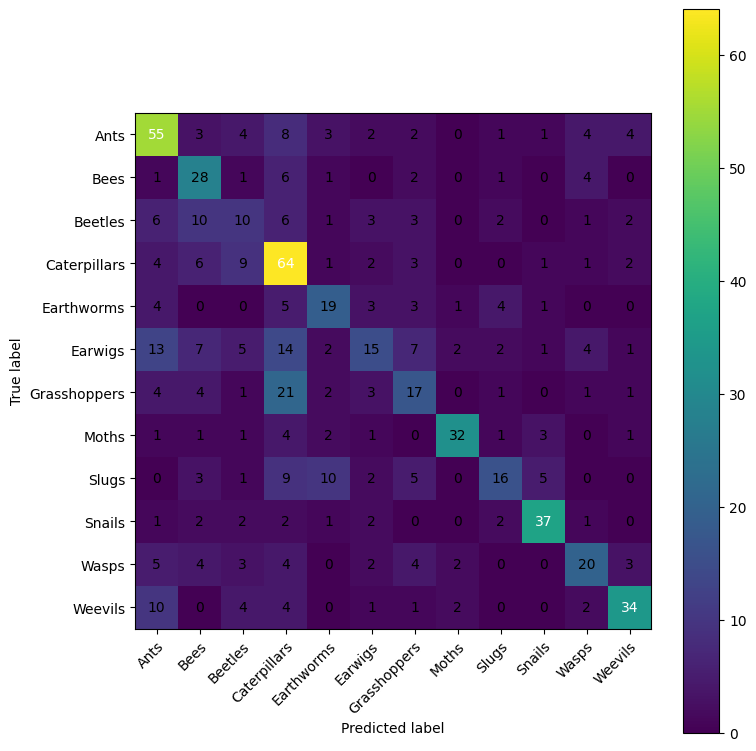


=== DONE (SVM) ===


In [6]:
USE_CACHE = True
cache_file_test = FEATURE_CACHE_DIR / "test_features.pkl"

if USE_CACHE and cache_file_test.exists():
    X_test, y_test = load_features(cache_file_test)
else:
    test_folder = os.path.join(cfg["YOLO_ROOT"], "test")
    test_image_paths, test_label_paths = load_paths(test_folder)
    X_test, y_test = extract_dataset_features(
        test_image_paths, test_label_paths, hog_desc,
        margin_ratio=cfg["CROP_MARGIN_RATIO"],
        min_crop=cfg["MIN_CROP_SIZE"],
        resize_to=cfg["RESIZE_TO"],
        desc="Test",
    )
    save_features(cache_file_test, X_test, y_test)

print(f"Test samples: {len(X_test)}")

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred, target_names=cfg["CLASS_NAMES"], digits=4))

cm = confusion_matrix(y_test, y_pred)
plot_confusion_matrix(cm, cfg["CLASS_NAMES"], os.path.join(cfg["OUT_ROOT"], "svm_cm_test.png"))

save_classification_report(
    Path(cfg["OUT_ROOT"]), y_test, y_pred, cfg["CLASS_NAMES"]
)

print("\n=== DONE (SVM) ===")